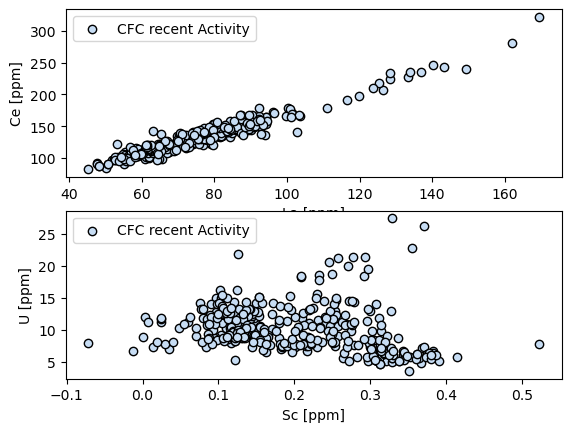

In [ ]:
# pandas: library untuk mengolah data tabel (mirip Excel), bisa baca file, filter, hitung statistik, dll
import pandas as pd 
# matplotlib: library visualisasi untuk membuat grafik (scatter, line, bar, dll)
import matplotlib.pyplot as plt

# membaca file Excel dan memasukkan datanya ke dalam DataFrame (struktur tabel di pandas)
# sheet_name='Supp_traces' berarti ambil data dari sheet tertentu di file Excel
my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')

# membuat “kanvas” kosong untuk menampung seluruh grafik (figure utama)
fig = plt.figure()
# membuat subplot pertama dari layout 2 baris 1 kolom (posisi atas)
# ax1 ini adalah area tempat grafik pertama akan digambar
ax1 = fig.add_subplot(2,1,1)
# membuat scatter plot (diagram titik)
# sumbu x = kolom La, sumbu y = kolom Ce dari dataset
# marker='o' bentuk titik bulat
# edgecolor='k' garis tepi titik warna hitam
# color='#c7ddf4' warna isi titik (biru muda)
# label digunakan untuk legenda
ax1.scatter(my_dataset.La, my_dataset.Ce, marker='o', edgecolor='k', color='#c7ddf4', label='CFC recent Activity')
# memberi label pada sumbu x (La dalam satuan ppm)
ax1.set_xlabel('La [ppm]')
# memberi label pada sumbu y (Ce dalam satuan ppm)
ax1.set_ylabel('Ce [ppm]')
# menampilkan legenda berdasarkan label yang diberikan sebelumnya
ax1.legend()

# membuat subplot kedua (posisi bawah) dalam layout yang sama (2 baris, 1 kolom)
ax2 = fig.add_subplot(2,1,2)
# scatter plot kedua
# sumbu x = Sc, sumbu y = U dari dataset
ax2.scatter(my_dataset.Sc, my_dataset.U, marker='o', edgecolor='k', color='#c7ddf4', label='CFC recent Activity')
# label sumbu x untuk grafik kedua
ax2.set_xlabel('Sc [ppm]')
# label sumbu y untuk grafik kedua
ax2.set_ylabel('U [ppm]')
# menampilkan legenda untuk grafik kedua
ax2.legend()

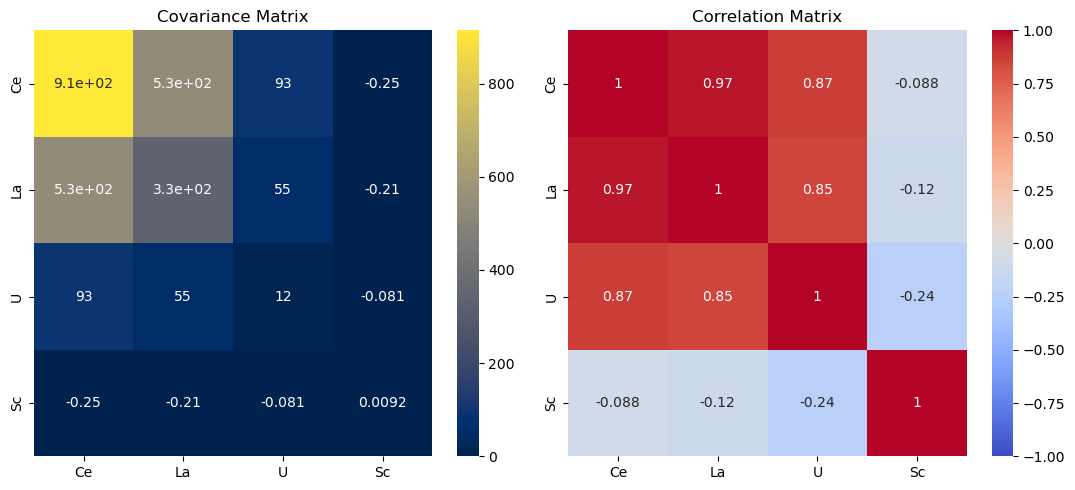

In [ ]:
# pandas: library untuk mengolah data berbentuk tabel (mirip Excel), bisa filtering, statistik, dll
import pandas as pd
# matplotlib: library untuk membuat visualisasi (grafik, plot, figure)
import matplotlib.pyplot as plt
# seaborn: library visualisasi berbasis matplotlib, khusus untuk grafik statistik (lebih estetik & mudah)
import seaborn as sns

# membaca file Excel dan mengambil data dari sheet 'Supp_traces'
# hasilnya berupa DataFrame (tabel)
my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')
# mengambil subset kolom tertentu saja (Ce, La, U, Sc)
# jadi analisis fokus ke 4 variabel ini
my_sub_dataset = my_dataset[['Ce','La','U','Sc']]

# menghitung covariance matrix
# covariance: mengukur apakah dua variabel berubah bersama (arah hubungan, tapi tidak dinormalisasi
cov = my_sub_dataset.cov()
# menghitung correlation matrix
# correlation: hubungan antar variabel dalam skala -1 sampai 1 (lebih mudah diinterpretasi)
cor = my_sub_dataset.corr()

# membuat figure (kanvas) dengan ukuran lebar 11 dan tinggi 5 inci
fig = plt.figure(figsize=(11,5))

# membuat subplot pertama dalam layout 1 baris 2 kolom (posisi kiri)
ax1 = fig.add_subplot(1,2,1)
# memberi judul pada plot pertama
ax1.set_title('Covariance Matrix')
# membuat heatmap dari covariance matrix
# annot=True → menampilkan nilai angka di setiap sel
# cmap='cividis' → skema warna
# ax=ax1 → ditampilkan di subplot pertama
sns.heatmap(cov, annot=True, cmap='cividis', ax=ax1)

# membuat subplot kedua (posisi kanan)
ax2 = fig.add_subplot(1,2,2)
# memberi judul pada plot kedua
ax2.set_title('Correlation Matrix')
# heatmap untuk correlation matrix
# vmin=-1, vmax=1 → memastikan skala warna dari -1 sampai 1 (standar korelasi)
# cmap='coolwarm' → warna biru (negatif) ke merah (positif)
sns.heatmap(cor, annot=True, vmin= -1, vmax=1,  cmap='coolwarm', ax=ax2)

# mengatur jarak antar subplot agar tidak saling tumpang tindih
fig.tight_layout()

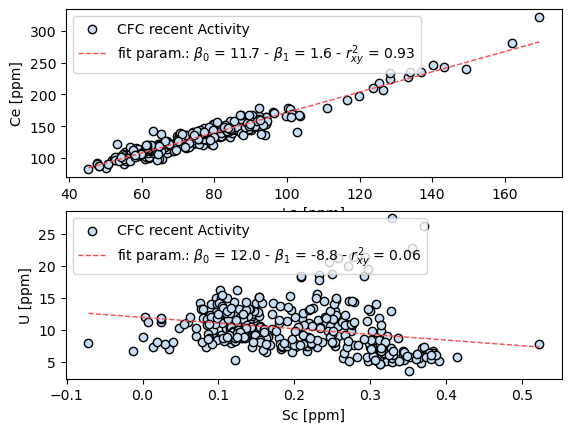

In [ ]:
# pandas: untuk membaca & mengolah data tabel (Excel, CSV, dll)
import pandas as pd
# scipy.stats: modul statistik → di sini dipakai untuk regresi linear (linregress)
import scipy.stats as st
# numpy: library numerik → dipakai untuk operasi array & membuat rentang nilai (linspace)
import numpy as np
# matplotlib: untuk membuat grafik/plot
import matplotlib.pyplot as plt

# membaca data dari file Excel (sheet: Supp_traces) ke dalam DataFrame
my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')

# membuat kanvas utama untuk grafik
fig = plt.figure()

# membuat subplot pertama (2 baris, 1 kolom → posisi atas)
ax1= fig.add_subplot(2,1,1)
# scatter plot: La (x) vs Ce (y)
# marker bulat, tepi hitam, warna biru muda
ax1.scatter(my_dataset.La, my_dataset.Ce, marker='o', edgecolor='k', color='#c7ddf4', label='CFC recent Activity')
# regresi linear sederhana
# b1 = slope (kemiringan garis)
# b0 = intercept (titik potong sumbu y)
# rho_value = koefisien korelasi (r)
# p_value = signifikansi statistik
# std_err = error standar slope
b1, b0, rho_value, p_value, std_err = st.linregress(my_dataset.La, my_dataset.Ce)
# membuat array nilai x dari minimum sampai maksimum La (untuk menggambar garis regresi)
x = np.linspace(my_dataset.La.min(),my_dataset.La.max())
# persamaan garis regresi: y = b0 + b1*x
y = b0 + b1*x
# menggambar garis regresi di atas scatter plot
# linestyle '--' → garis putus-putus
# label berisi:
#   β0 = intercept
#   β1 = slope
#   r^2 = koefisien determinasi (kekuatan hubungan)
ax1.plot(x, y, linewidth=1, color='#ff464a', linestyle='--', label=r"fit param.: $\beta_0$ = " + '{:.1f}'.format(b0) + r" - $\beta_1$ = "  + '{:.1f}'.format(b1) + r" - $r_{xy}^{2}$ = " + '{:.2f}'.format(rho_value**2))
# label sumbu x
ax1.set_xlabel('La [ppm]')
# label sumbu y
ax1.set_ylabel('Ce [ppm]')
# menampilkan legenda di posisi kiri atas
ax1.legend(loc= 'upper left')

# ================= subplot kedua =================
# subplot kedua (posisi bawah)
ax2 = fig.add_subplot(2,1,2)
# scatter plot: Sc (x) vs U (y)
ax2.scatter(my_dataset.Sc, my_dataset.U, marker='o', edgecolor='k', color='#c7ddf4', label='CFC recent Activity')
# regresi linear untuk Sc vs U
b1, b0, rho_value, p_value, std_err = st.linregress(my_dataset.Sc, my_dataset.U)
# range nilai x berdasarkan Sc
x = np.linspace(my_dataset.Sc.min(),my_dataset.Sc.max())
# persamaan garis regresi
y = b0 + b1*x
# plot garis regresi + info parameter
ax2.plot(x, y, linewidth=1, color='#ff464a', linestyle='--', label=r"fit param.: $\beta_0$ = " + '{:.1f}'.format(b0) + r" - $\beta_1$ = "  + '{:.1f}'.format(b1) + r" - $r_{xy}^{2}$ = " + '{:.2f}'.format(rho_value**2))
# label sumbu x
ax2.set_xlabel('Sc [ppm]')
# label sumbu y
ax2.set_ylabel('U [ppm]')
# legenda subplot kedua
ax2.legend(loc= 'upper left')



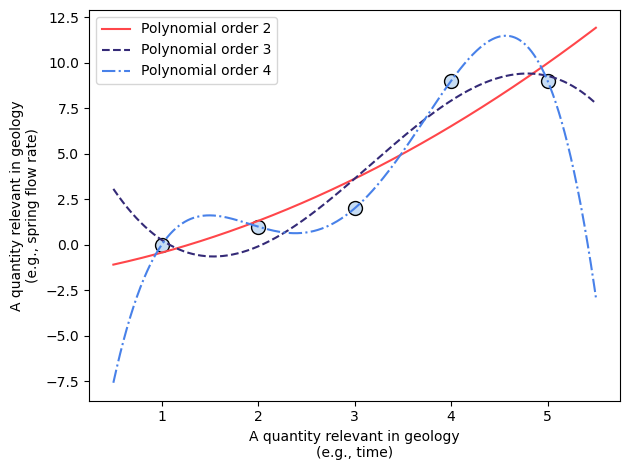

In [1]:
import numpy as np                      # numpy: untuk perhitungan numerik & array
import matplotlib.pyplot as plt         # matplotlib: untuk membuat grafik

x = np.arange(1,6)                      # membuat array [1,2,3,4,5] → variabel x
y = np.array([0,1,2,9,9])               # data y (nilai yang mau dipelajari hubungannya dengan x)

fig, ax = plt.subplots()                # membuat figure dan area plot (axes)
ax.scatter(x, y,                        # membuat scatter plot (diagram titik)
           marker='o',                  # bentuk titik bulat
           s=100,                       # ukuran titik
           color='#c7ddf4',             # warna isi titik
           edgecolor='k')               # warna tepi titik (hitam)

orders = np.array([2,3,4])              # derajat polinomial yang akan dicoba (orde 2, 3, 4)
colors = ['#ff464a','#342a77','#4881e9']# warna masing-masing model
linestiles = ['-','--','-.']            # gaya garis (solid, putus-putus, titik-putus)

for order, color, linestile in zip(orders, colors, linestiles):  # loop untuk tiap model
    betas = np.polyfit(x, y, order)     # menghitung koefisien polinomial terbaik (fitting)
    func = np.poly1d(betas)             # mengubah koefisien jadi fungsi matematika
    
    x1 = np.linspace(0.5, 5.5, 1000)    # membuat banyak titik x (biar kurva halus)
    y1 = func(x1)                       # menghitung nilai y dari fungsi polinomial
    
    ax.plot(x1, y1,                     # menggambar kurva hasil fitting
            color=color,                # warna garis
            linestyle=linestile,        # jenis garis
            label="Polynomial order " + str(order))  # label untuk legenda

ax.legend()                             # menampilkan legenda (keterangan tiap garis)
ax.set_xlabel('A quantity relevant in geology\n(e.g., time)')   # label sumbu x (pakai baris baru)
ax.set_ylabel('A quantity relevant in geology\n(e.g., spring flow rate)')  # label sumbu y
fig.tight_layout()                      # merapikan layout agar tidak bertumpuk

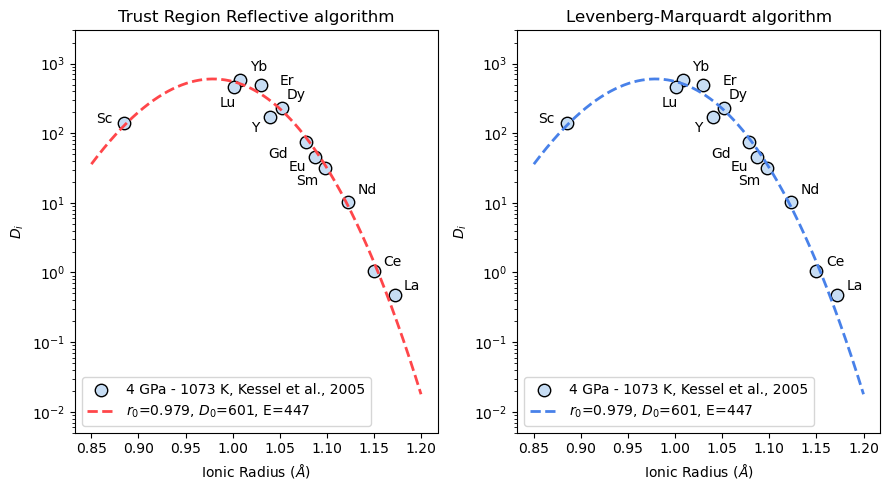

In [2]:
import numpy as np                          # numpy: operasi numerik (array, exp, linspace, dll)
import matplotlib.pyplot as plt             # matplotlib: untuk plotting grafik
from scipy.optimize import curve_fit        # curve_fit: fitting model non-linear ke data

def func(r, r0, D0, E):                     # fungsi model (non-linear) untuk fitting
    R = 8.314462618                         # konstanta gas (J/mol·K)
    scale = 1e-21                           # faktor skala untuk penyesuaian satuan
    T = 800 + 273.15                        # suhu dalam Kelvin (800°C)
    Na = 6.02e23                            # bilangan Avogadro
    return D0*np.exp((-4*np.pi*E*Na*((r0/2)*(r-r0)**2+(1/3)*(r-r0)**3)*scale)/(R*T))
    # persamaan eksponensial → model geokimia (lattice strain)

def add_elements(ax):                       # fungsi untuk menambahkan label unsur di plot
    names = ['La','Ce','Nd','Sm','Eu','Gd','Dy','Er','Yb','Lu','Y','Sc']  # nama unsur
    annotate_xs = np.array([1.172+0.01,1.15+0.01,1.123+0.01,1.098-0.031,1.087-0.028,
                            1.078-0.04,1.052+0.005,1.03+0.02,1.008+0.01,
                            1.001-0.015,1.04-0.02,0.885-0.03])             # posisi x label
    annotate_ys = np.array([0.468+0.1,1.050+0.2,10.305+3,31.283-13,45.634-17,
                            74.633-30,229.279+80,485.500,583.828+200,
                            460.404-220,172.844-70,141.630])               # posisi y label
    
    for name, annotate_x, annotate_y in zip(names, annotate_xs, annotate_ys):
        ax.annotate(name, (annotate_x, annotate_y))  # menaruh nama unsur di plot

Di = np.array([0.468,1.050,10.305,31.283,45.634,74.633,229.279,485.500,
               583.828,460.404,172.844,141.630])     # data D_i (partition coefficient)

I_r = np.array([1.172,1.15,1.123,1.098,1.087,1.078,1.052,1.03,
                1.008,1.001,1.04,0.885])             # ionic radius tiap unsur

fig = plt.figure(figsize=(9,5))                      # membuat kanvas (2 plot berdampingan)

# ===================== subplot 1: TRF =====================
ax1 = fig.add_subplot(1,2,1)                         # subplot kiri
ax1.set_title("Trust Region Reflective algorithm")  # judul

ax1.scatter(I_r, Di, s=80, color='#c7ddf4', edgecolors='k',
            label='4 GPa - 1073 K, Kessel et al., 2005')  # plot data asli

popt1, pcov1 = curve_fit(func, I_r, Di, method='trf',
                         bounds=([0.8,0,0],[1.3,1000,1000]))
# fitting model dengan metode TRF + batas parameter
# hasil: popt1 = [r0, D0, E]

x1 = np.linspace(0.85,1.2,1000)                     # membuat x halus
y1 = func(x1, popt1[0], popt1[1], popt1[2])         # menghitung kurva model

ax1.plot(x1, y1, color='#ff464a', linewidth=2, linestyle='--',
         label=r'$r_0$=' + '{:.3f}'.format(popt1[0]) +
               r', $D_0$=' + '{:.0f}'.format(popt1[1]) +
               ', E=' + '{:.0f}'.format(popt1[2]))
# plot hasil fitting + tampilkan parameter

add_elements(ax=ax1)                                # tambahkan label unsur
ax1.set_yscale('log')                               # sumbu y log (karena range besar)
ax1.set_xlabel(r'Ionic Radius ($\AA$)')              # label x
ax1.set_ylabel(r'$D_i$')                             # label y
ax1.set_ylim(0.005,3000)                            # batas y
ax1.legend()                                        # legenda

# ===================== subplot 2: LM =====================
ax2 = fig.add_subplot(1,2,2)                         # subplot kanan
ax2.set_title("Levenberg-Marquardt algorithm")       # judul

ax2.scatter(I_r, Di, s=80, color='#c7ddf4', edgecolors='k',
            label='4 GPa - 1073 K, Kessel et al., 2005')  # data sama

popt2, pcov2 = curve_fit(func, I_r, Di, method='lm',
                         p0=(1.1,100,100))
# fitting dengan metode LM (butuh tebakan awal p0)

x2 = np.linspace(0.85,1.2,1000)                     # x halus
y2 = func(x2, popt2[0], popt2[1], popt2[2])         # kurva model

ax2.plot(x2, y2, color='#4881e9', linewidth=2, linestyle='--',
         label=r'$r_0$=' + '{:.3f}'.format(popt2[0]) +
               r', $D_0$=' + '{:.0f}'.format(popt2[1]) +
               ', E=' + '{:.0f}'.format(popt2[2]))
# plot hasil fitting LM

add_elements(ax=ax2)                                # label unsur
ax2.set_yscale('log')                               # skala log
ax2.set_xlabel(r'Ionic Radius ($\AA$)')              # label x
ax2.set_ylabel(r'$D_i$')                             # label y
ax2.set_ylim(0.005,3000)                            # batas y
ax2.legend()                                        # legenda

fig.tight_layout()                                  # merapikan layout